# Chen 2004 – NNSE Neutral-Set Sampling

Uses the Chen 2004 budding yeast cell-cycle model (output: CLB2).  
Model setup via `wsbw_pipeline.py`; NNSE core functions from `wsbw_nnse.py`.  
Bin thresholds: logspace + extra lower bins (Tyson-style).  
Plots saved to `../plots/ChenNNSE/`, results to `../results/nnse/`.

In [11]:
%matplotlib inline

import math
import os
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(ROOT / ".mplconfig"))

from wsbw_pipeline import SPECS, prepare_models
from wsbw_nnse import objective_factory, fill_initial_population, nnse_step

In [12]:
# ── Configuration ─────────────────────────────────────────────────────────────
MODEL_KEY = "chen2004"
SIGMA     = 0.01
MAX_STEPS = int(5e5)
STABILIZATION    = int(1e4)
BURN_IN_FALLBACK = MAX_STEPS // 2
SEED      = 42

# Bin thresholds: logspace(0.1, 250) + 3 extra lower bins prepended
MAX_VALUE = 250.0
N_BASE    = 30
N_EXTRA   = 3
base      = np.logspace(np.log10(0.1), np.log10(MAX_VALUE), N_BASE + 1)
ratio     = base[1] / base[0]
extra_low = base[0] / (ratio ** np.arange(N_EXTRA, 0, -1))
bin_thresholds = np.concatenate([extra_low, base])
bin_thresholds[-1] = 1000.0
N_VEC = len(bin_thresholds)
MIN_FILLED = N_VEC - 2

PLOT_DIR   = ROOT / "plots" / "ChenNNSE"
RESULT_DIR = ROOT / "results" / "nnse"
PLOT_DIR.mkdir(parents=True, exist_ok=True)
RESULT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Bins : {N_VEC}  ({bin_thresholds[0]:.3e} … {bin_thresholds[-1]:.3e})")
print(f"NNSE : sigma={SIGMA}, max_steps={MAX_STEPS}, min_filled={MIN_FILLED}, stab={STABILIZATION}")

Bins : 34  (4.573e-02 … 1.000e+03)
NNSE : sigma=0.01, max_steps=500000, min_filled=32, stab=10000


In [13]:
# ── Model setup ───────────────────────────────────────────────────────────────
audit      = prepare_models()
spec       = next(s for s in SPECS if s.key == MODEL_KEY)
objective, p0, param_names, reference = objective_factory(spec, audit[MODEL_KEY])
t_ref = reference["time"]
y_ref = reference["signal"]

print(f"Model      : {spec.label}")
print(f"Output     : {spec.output}")
print(f"Parameters : {len(param_names)}")
print(param_names)

Model      : Chen 2004
Output     : CLB2
Parameters : 136
['b0', 'bub2h', 'bub2l', 'C0', 'Dn3', 'ebudb5', 'ebudn2', 'ebudn3', 'ec1b2', 'ec1b5', 'ec1k2', 'ec1n2', 'ec1n3', 'ef6b2', 'ef6b5', 'ef6k2', 'ef6n2', 'ef6n3', 'eicdhb2', 'eicdhb5', 'eicdhn2', 'eicdhn3', 'eorib2', 'eorib5', 'esbfb5', 'esbfn2', 'esbfn3', 'J20ppx', 'Jacdh', 'Jaiep', 'Jamcm', 'Jasbf', 'Jatem', 'Jd2c1', 'Jd2f6', 'Jicdh', 'Jiiep', 'Jimcm', 'Jisbf', 'Jitem', 'Jn3', 'Jpds', 'Jspn', 'ka15_p', 'ka15_p_p', 'ka15p', 'ka20_p', 'ka20_p_p', 'kacdh_p', 'kacdh_p_p', 'kaiep', 'kamcm', 'kasb2', 'kasb5', 'kasbf', 'kasesp', 'kasf2', 'kasf5', 'kasrent', 'kasrentp', 'kaswi', 'kd14', 'kd1c1', 'kd1f6', 'kd1pds_p', 'kd20', 'kd2c1', 'kd2f6', 'kd2pds_p_p', 'kd3c1', 'kd3f6', 'kd3pds_p_p', 'kdb2_p', 'kdb2_p_p', 'kdb2p', 'kdb5_p', 'kdb5_p_p', 'kdbud', 'kdcdh', 'kdib2', 'kdib5', 'kdiesp', 'kdif2', 'kdif5', 'kdirentp', 'kdn2', 'kdnet', 'kdori', 'kdppx_p', 'kdppx_p_p', 'kdspn', 'kdswi', 'KEZ', 'KEZ2', 'ki15', 'kicdh_p', 'kicdh_p_p', 'kiiep', 'kim

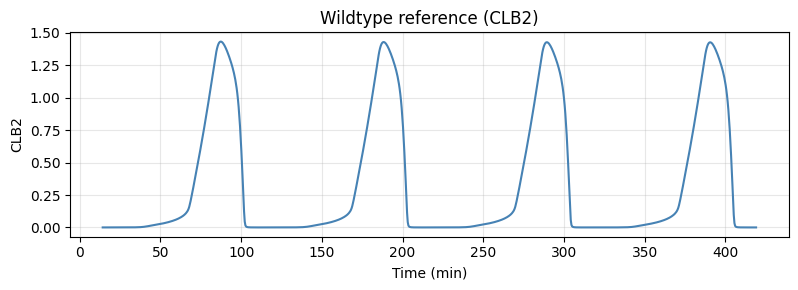

In [14]:
# ── Reference trace ───────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3))
ax.plot(t_ref, y_ref, lw=1.5, color="steelblue")
ax.set_title(f"Wildtype reference ({spec.output})")
ax.set_xlabel("Time (min)")
ax.set_ylabel(spec.output)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(PLOT_DIR / "01_reference_trace.png", dpi=150)
plt.show()

In [ ]:
# ── Run NNSE ──────────────────────────────────────────────────────────────────
rng = np.random.default_rng(SEED)
xs, fs = fill_initial_population(objective, p0, bin_thresholds, rng, k_initial=1)

swap_count        = np.zeros(N_VEC)
opportunity_count = np.zeros(N_VEC)
best_history:     list[float]      = []
neutral_points:   list[np.ndarray] = []
neutral_values:   list[float]      = []
convergence_step  = None
remaining_stab    = None
in_burnin         = False
start             = time.time()

for step in range(MAX_STEPS):
    xs, fs, swaps = nnse_step(xs, fs, objective, p0, bin_thresholds, rng, SIGMA)
    finite = [fx for fx in fs if fx is not None and math.isfinite(fx)]
    best   = min(finite) if finite else math.inf
    best_history.append(best)
    filled = sum(x is not None for x in xs)

    if not in_burnin and filled >= MIN_FILLED:
        convergence_step = step
        remaining_stab   = STABILIZATION
        in_burnin        = True
        print(f"  Convergence at step {step}: {filled}/{N_VEC} filled. "
              f"Running {STABILIZATION} stabilisation steps.")
    if not in_burnin and step >= BURN_IN_FALLBACK:
        in_burnin = True
        print(f"  Fallback burn-in triggered at step {step}.")

    if in_burnin:
        # swaps from wsbw_nnse.nnse_step is a list of (upper_idx, lower_idx) tuples
        swap_tuples = set(swaps)
        for i in range(1, N_VEC):
            if fs[i] is not None and fs[i - 1] is not None:
                opportunity_count[i] += 1
                if (i, i - 1) in swap_tuples:
                    swap_count[i] += 1
        for x, fx in zip(xs, fs):
            if x is not None and fx is not None and fx <= bin_thresholds[0]:
                neutral_points.append(x.copy())
                neutral_values.append(float(fx))

    if remaining_stab is not None:
        remaining_stab -= 1
        if remaining_stab <= 0:
            break

    if step == 0 or (step + 1) % max(1, MAX_STEPS // 20) == 0:
        print(f"  step {step + 1:5d}: filled={filled}/{N_VEC}, best={best:.3e}, "
              f"neutral={len(neutral_points)}, {time.time() - start:.0f}s")

elapsed = time.time() - start
volume_ratios = np.divide(
    swap_count, opportunity_count,
    out=np.full(N_VEC, np.nan),
    where=opportunity_count > 0,
)
neutral = (np.unique(np.array(neutral_points), axis=0)
           if neutral_points else np.empty((0, len(p0))))

n_filled = sum(x is not None for x in xs)
print(f"\nDone in {elapsed:.0f}s | neutral={len(neutral)} | filled={n_filled}/{N_VEC}")

Error: CVODE Error: CV_CONV_FAILURE, Module: CVODES, Function: CVode, Message: At t = 323.524 and h = 1.71323e-06, the corrector convergence test failed repeatedly or with |h| = hmin.


  step     1: filled=1/34, best=4.987e+02, neutral=0, 0s


Error: CVODE Error: CV_CONV_FAILURE, Module: CVODES, Function: CVode, Message: At t = 24.2182 and h = 5.5987e-13, the corrector convergence test failed repeatedly or with |h| = hmin.
Error: CVODE Error: CV_ERR_FAILURE, Module: CVODES, Function: CVode, Message: At t = 47.722 and h = 6.189e-09, the error test failed repeatedly or with |h| = hmin.
Error: CVODE Error: CV_ERR_FAILURE, Module: CVODES, Function: CVode, Message: At t = 236.806 and h = 5.51967e-10, the error test failed repeatedly or with |h| = hmin.
Error: CVODE Error: CV_CONV_FAILURE, Module: CVODES, Function: CVode, Message: At t = 14.7128 and h = 3.2133e-13, the corrector convergence test failed repeatedly or with |h| = hmin.
Error: CVODE Error: CV_CONV_FAILURE, Module: CVODES, Function: CVode, Message: At t = 78.1582 and h = 2.39967e-12, the corrector convergence test failed repeatedly or with |h| = hmin.
Error: CVODE Error: CV_ERR_FAILURE, Module: CVODES, Function: CVode, Message: At t = 64.1108 and h = 5.79291e-10, the e

In [ ]:
# ── Save result ───────────────────────────────────────────────────────────────
stamp   = time.strftime("%Y%m%d_%H%M%S")
out_npz = RESULT_DIR / f"chen2004_nnse_{stamp}.npz"

final_x = np.array([x if x is not None else np.full(len(p0), np.nan) for x in xs])
final_f = np.array([fx if fx is not None else np.nan for fx in fs], dtype=float)

np.savez_compressed(
    out_npz,
    neutral_points           = neutral,
    neutral_objective_values = np.array(neutral_values, dtype=float),
    final_population         = final_x,
    final_objective_values   = final_f,
    p0                       = p0,
    parameter_names          = np.array(param_names, dtype=object),
    bin_thresholds           = bin_thresholds,
    volume_ratios            = volume_ratios,
    swap_count               = swap_count,
    opportunity_count        = opportunity_count,
    best_history             = np.array(best_history, dtype=float),
    reference_time           = t_ref,
    reference_signal         = y_ref,
)
print(f"Saved: {out_npz}")

In [ ]:
# ── Volume ratios + best objective ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

valid = ~np.isnan(volume_ratios[1:])
bidx  = np.where(valid)[0] + 1
axes[0].bar(bidx, volume_ratios[1:][valid], color="steelblue", alpha=0.8, width=0.7)
axes[0].set_title("Volume ratios V[i−1]/V[i]")
axes[0].set_xlabel("Bin boundary i")
axes[0].set_ylabel("Swap rate")
axes[0].grid(alpha=0.3)

axes[1].semilogy(best_history, lw=1, color="steelblue")
if convergence_step is not None:
    axes[1].axvline(convergence_step, color="red", ls="--", lw=0.8, label="convergence")
    axes[1].legend()
axes[1].set_title("Best objective over steps")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Objective (log scale)")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR / "02_nnse_diagnostics.png", dpi=150)
plt.show()

In [ ]:
# ── Neutral set: parameter fold-changes from wildtype ─────────────────────────
if len(neutral) == 0:
    print("No neutral points collected. Try more steps or lower bin_thresholds[0].")
else:
    ratios = neutral / p0

    fig, ax = plt.subplots(figsize=(max(8, len(param_names)), 4))
    ax.boxplot([ratios[:, i] for i in range(len(param_names))],
               labels=param_names, patch_artist=True,
               boxprops=dict(facecolor="lightsteelblue", alpha=0.7))
    ax.axhline(1.0, color="red", lw=1.2, ls="--", label="wildtype")
    ax.set_title(f"Neutral set parameter ratios  (n={len(neutral)})")
    ax.set_ylabel("p / p₀")
    ax.tick_params(axis="x", rotation=40)
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOT_DIR / "03_neutral_ratios.png", dpi=150)
    plt.show()
    print(f"Neutral set size: {len(neutral)}")
    print(f"Median |log2 fold-change|: {float(np.median(np.abs(np.log2(ratios)))):.3f}")